In [2]:
import sys
sys.path.append('..')

from src.data import load_arrays, get_dataloaders
from src.models import DeepCNN
from src.evaluate import get_predictions

import torch

# 1. ricrea il mapping label — deve essere IDENTICO a quello usato in training
import pandas as pd
df_train = pd.read_csv('../dataset/processed/train_final_index.csv')
label2idx = {emotion: idx for idx, emotion in enumerate(sorted(df_train['emotion'].unique()))}
class_names = sorted(label2idx, key=label2idx.get)

# 2. ricarica dati precomputati (mean/std/immagini test) e dataloader
data = load_arrays('../dataset/processed/fer_arrays.npz')
_, _, test_loader = get_dataloaders('../dataset/processed/fer_arrays.npz', label2idx)

# 3. ricrea il modello e carica i pesi del tuo checkpoint migliore
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DeepCNN(num_classes=7).to(device)
model.load_state_dict(torch.load('../results/deep_cnn_focal_lightweight.pt', map_location=device))
model.eval()

# 4. rigenera y_true/y_pred (non esistono più in questo notebook)
y_true, y_pred = get_predictions(model, test_loader, device)

print(f"Test set: {len(y_true)} campioni, accuracy: {(y_true == y_pred).mean():.3f}")

/tmp/ipykernel_43202/1426384913.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('../results/deep_cnn_focal_lightweight.pt', map_locatio

Test set: 7092 campioni, accuracy: 0.649


In [3]:
import numpy as np
import matplotlib.pyplot as plt

fear_idx = label2idx['fear']

# indici nel test set dove la label vera è 'fear' ma la predizione è sbagliata
fear_mask = (y_true == fear_idx) & (y_pred != fear_idx)
fear_error_indices = np.where(fear_mask)[0]

print(f"Errori su 'fear': {len(fear_error_indices)} su {(y_true == fear_idx).sum()} totali")

# distribuzione di COSA il modello ha predetto al posto di 'fear'
wrong_preds = y_pred[fear_error_indices]
for idx in np.argsort(-np.bincount(wrong_preds, minlength=7)):
    if np.bincount(wrong_preds, minlength=7)[idx] > 0:
        print(f"  predetto come '{class_names[idx]}': {np.bincount(wrong_preds, minlength=7)[idx]} volte")

Errori su 'fear': 597 su 1013 totali
  predetto come 'sad': 228 volte
  predetto come 'angry': 131 volte
  predetto come 'neutral': 107 volte
  predetto come 'surprise': 102 volte
  predetto come 'happy': 24 volte
  predetto come 'disgust': 5 volte


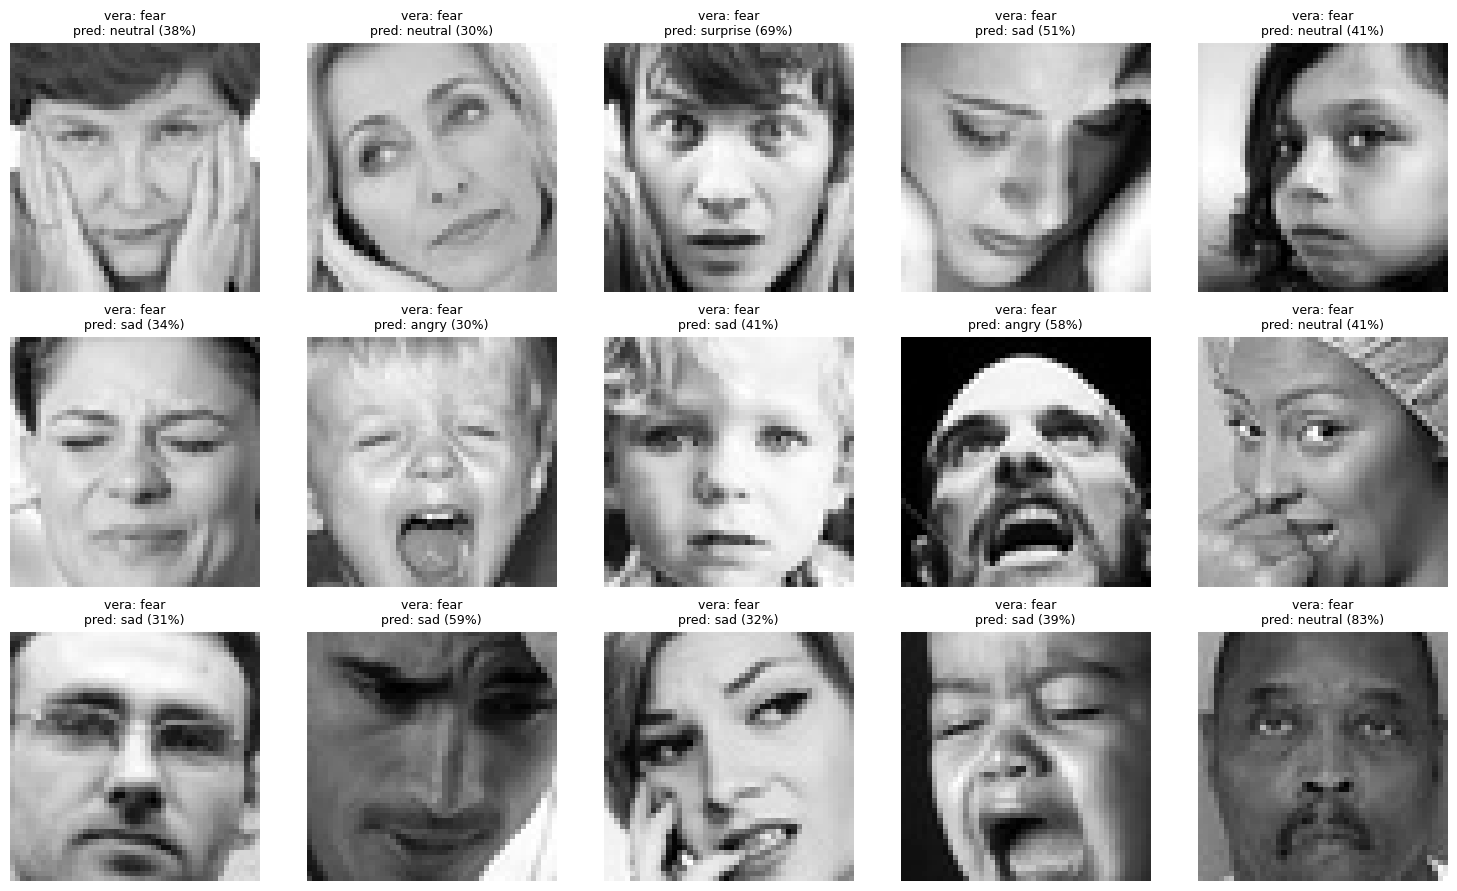

In [4]:
model.eval()
device = next(model.parameters()).device

n_samples = 15
sample_indices = np.random.choice(fear_error_indices, min(n_samples, len(fear_error_indices)), replace=False)

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()

for ax, idx in zip(axes, sample_indices):
    img = data['X_test'][idx]  # immagine grezza uint8, prima della normalizzazione
    true_label = class_names[y_true[idx]]
    pred_label = class_names[y_pred[idx]]

    # confidenza del modello sulla predizione sbagliata
    img_tensor = torch.from_numpy(img.astype(np.float32) / 255.0)
    img_tensor = (img_tensor - data['mean']) / data['std']
    img_tensor = img_tensor.unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(model(img_tensor), dim=1).cpu().numpy()[0]
    confidence = probs[y_pred[idx]]

    ax.imshow(img, cmap='gray')
    ax.set_title(f"vera: {true_label}\npred: {pred_label} ({confidence:.0%})", fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

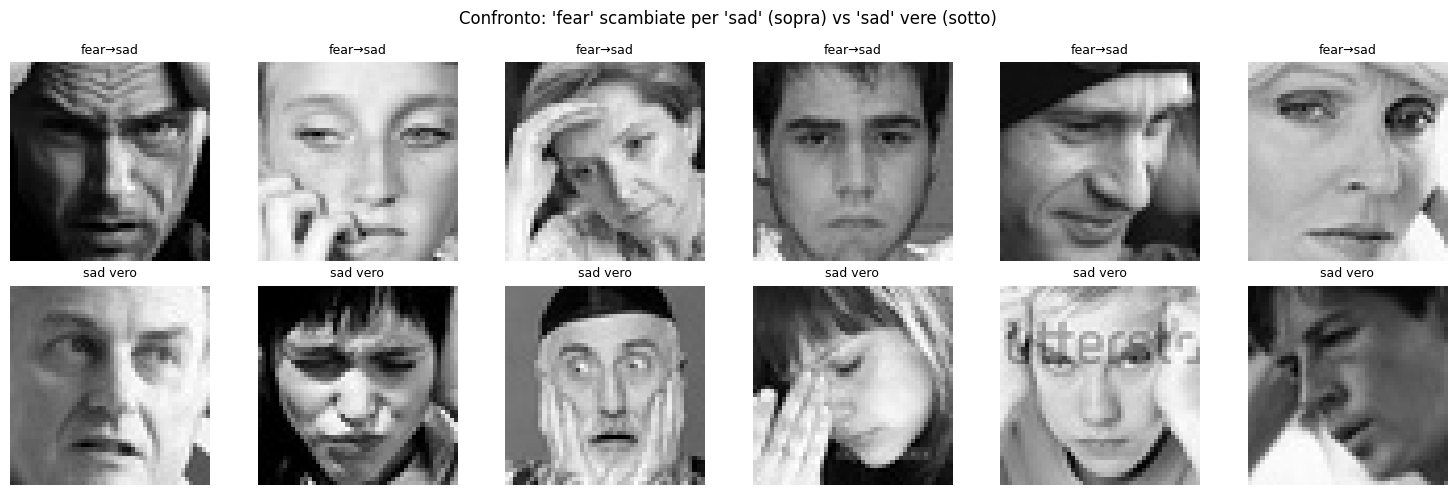

In [5]:
fear_as_sad = fear_error_indices[y_pred[fear_error_indices] == label2idx['sad']]

fig, axes = plt.subplots(2, 6, figsize=(15, 5))

for i in range(6):
    if i < len(fear_as_sad):
        idx = fear_as_sad[i]
        axes[0, i].imshow(data['X_test'][idx], cmap='gray')
        axes[0, i].set_title('fear→sad', fontsize=9)
        axes[0, i].axis('off')

    # veri esempi di sad, per confronto visivo
    sad_indices = np.where(y_true == label2idx['sad'])[0]
    idx2 = sad_indices[i]
    axes[1, i].imshow(data['X_test'][idx2], cmap='gray')
    axes[1, i].set_title('sad vero', fontsize=9)
    axes[1, i].axis('off')

plt.suptitle("Confronto: 'fear' scambiate per 'sad' (sopra) vs 'sad' vere (sotto)")
plt.tight_layout()
plt.show()